In [14]:
import pandas as pd
import glob
import scanpy as sc

In [44]:
test_benchmark_files = glob.glob("/data/sarkar_lab/insitupy_demo_data_xenium/*/*.csv")

In [17]:
# read number of cells and number of genes from each file and store in a dataframe
h5ad_files = glob.glob("/data/sarkar_lab/insitupy_demo_data_xenium/*.h5ad")
file_info = []
for h5ad_file in h5ad_files:
    adata = sc.read_h5ad(h5ad_file)
    num_cells = adata.n_obs
    num_genes = adata.n_vars
    experiment_name = h5ad_file.split("/")[-1].replace(".h5ad", "")
    file_info.append({'experiment': experiment_name, 'num_cells': num_cells, 'num_genes': num_genes})
    del adata  # free memory
file_info_df = pd.DataFrame(file_info)

In [25]:
file_info_df

,experiment,num_cells,num_genes
0,xenium_human_skin_melanoma,87499,382
1,xenium_human_brain_cancer,816769,480
2,xenium_human_kidney_nondiseased,97560,377
3,xenium_human_lung_cancer,162254,377
4,xenium_human_lymph_node,377985,377
5,xenium_human_lymph_node_5k,708983,4624
6,xenium_human_pancreatic_cancer,190965,474
7,xenium_human_breast_cancer,167780,313


In [45]:
df_list = []
for f in test_benchmark_files:
    df = pd.read_csv(f)
    # Extract name of the experiment from the file path
    experiment_name = f.split("/")[-2]
    # remove "_index" 
    experiment_name = experiment_name.replace("_index", "")
    df['experiment'] = experiment_name
    df_list.append(df)

In [46]:
df_all = pd.concat(df_list, ignore_index=True)

In [47]:
#df_all = pd.merge(df_all, file_info_df, on='experiment')

In [48]:
df_all

,query_idx,cluster_id,budget,matched_gt,matched_leaf,matched_budget,search_time,baseline_time,experiment
0,301,1,189.430309,True,True,81.416071,0.006204,5.615099,xenium_human_skin_melanoma
1,457,0,167.719218,True,True,53.975176,0.006687,6.413544,xenium_human_skin_melanoma
2,416,1,189.430309,True,True,69.324286,0.005751,5.728292,xenium_human_skin_melanoma
3,82,5,215.963601,True,True,65.404513,0.015185,2.908104,xenium_human_skin_melanoma
4,79,2,174.854662,True,True,72.108620,0.004831,4.720362,xenium_human_skin_melanoma
...,...,...,...,...,...,...,...,...,...
1395,1387,1,221.229611,True,True,91.196119,0.005294,15.113822,xenium_human_lung_cancer
1396,52,0,204.228495,True,True,101.705962,0.014020,15.415307,xenium_human_lung_cancer
1397,1067,2,231.852274,True,True,92.992326,0.004700,12.283487,xenium_human_lung_cancer
1398,1649,1,221.229611,True,True,106.058703,0.005202,14.603771,xenium_human_lung_cancer


In [49]:
df_all.experiment.unique()

array(['xenium_human_skin_melanoma', 'xenium_human_kidney_nondiseased',
       'xenium_human_breast_cancer', 'xenium_human_pancreatic_cancer',
       'xenium_human_lymph_node', 'xenium_human_brain_cancer',
       'xenium_human_lung_cancer'], dtype=object)

In [50]:
file_info_df.experiment.unique()

array(['xenium_human_skin_melanoma', 'xenium_human_brain_cancer',
       'xenium_human_kidney_nondiseased', 'xenium_human_lung_cancer',
       'xenium_human_lymph_node', 'xenium_human_lymph_node_5k',
       'xenium_human_pancreatic_cancer', 'xenium_human_breast_cancer'],
      dtype=object)

/tmp/ipykernel_1198668/3501101289.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=12)


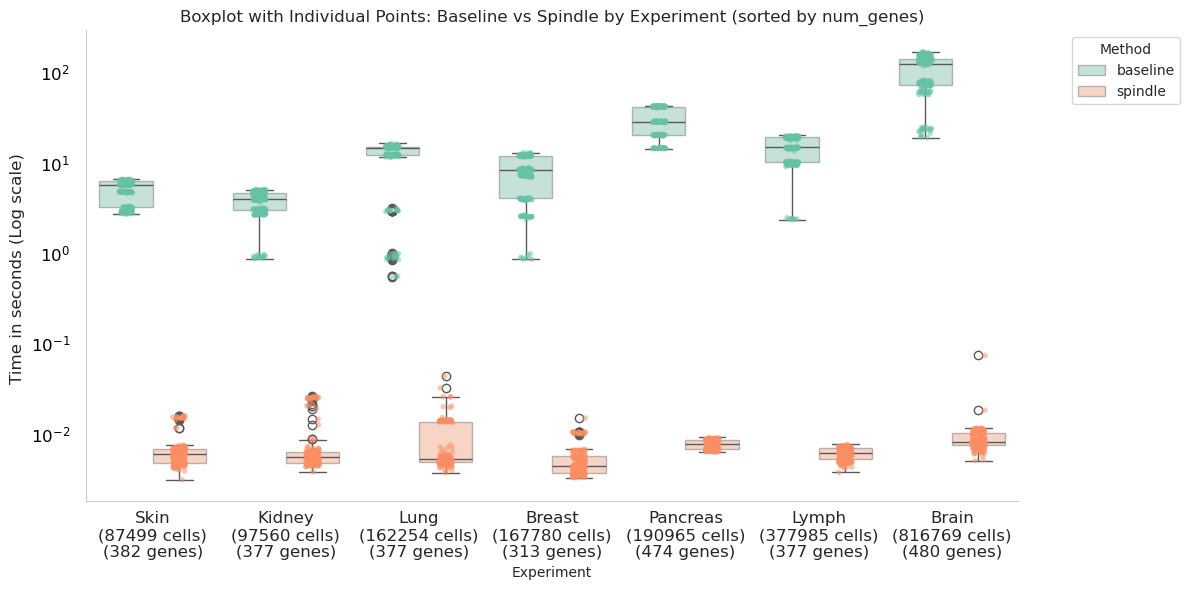

In [97]:
# Create boxplot with strip plots of search_time and baseline_time using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Merge file_info_df with df_all to get num_cells and num_genes
df_melted = df_all.melt(id_vars=['experiment'], value_vars=['search_time', 'baseline_time'], var_name='time_type', value_name='time')

# Merge with file_info to get num_cells and num_genes
df_melted = df_melted.merge(file_info_df, on='experiment', how='left')

# Rename time_type values: baseline_time -> baseline, search_time -> spindle
df_melted['method'] = df_melted['time_type'].map({'baseline_time': 'baseline', 'search_time': 'spindle'})

# Create mapping with specific meaningful names
short_name_map = {
    'xenium_human_skin_melanoma': 'Skin',
    'xenium_human_kidney_nondiseased': 'Kidney',
    'xenium_human_breast_cancer': 'Breast',
    'xenium_human_pancreatic_cancer': 'Pancreas',
    'xenium_human_lymph_node': 'Lymph',
    'xenium_human_lung_cancer': 'Lung',
    'xenium_human_brain_cancer': 'Brain'
}

# Sort by num_genes and create ordered list
exp_order = df_melted.drop_duplicates(subset=['experiment']).sort_values(['num_cells'])['experiment'].tolist()

# Create figure with larger size for better readability
fig, ax = plt.subplots(figsize=(12, 6))

# Create boxplot sorted by num_genes
sns.boxplot(x='experiment', y='time', hue='method',
            data=df_melted, ax=ax, order=exp_order, 
            hue_order=['baseline', 'spindle'],
            patch_artist=True)  # Enable transparency

# Make boxplot patches transparent
for patch in ax.patches:
    patch.set_alpha(0.4)

# Remove horizontal gridlines
ax.set_axisbelow(True)
ax.yaxis.grid(False)

# Overlay strip plots with jitter and dodging for better visibility of individual points
sns.stripplot(x='experiment', y='time', hue='method', data=df_melted, 
              jitter=True, dodge=True, alpha=0.5, size=4, ax=ax, order=exp_order, hue_order=['baseline', 'spindle'])

# Remove duplicate legend entries from stripplot
handles, labels = ax.get_legend_handles_labels()
# Keep only the first 2 entries (boxplot legend for baseline and spindle)
ax.legend(handles[:2], 
         labels[:2],
         title='Method', 
         bbox_to_anchor=(1.05, 1), 
         loc='upper left'
)

# Update x-axis labels with short names and stats
exp_info = file_info_df.set_index('experiment').loc[exp_order]
x_labels = [f"{short_name_map[exp]}\n({row['num_cells']} cells)\n({row['num_genes']} genes)" 
            for exp, (_, row) in zip(exp_order, exp_info.iterrows())]
ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=12)
#ax.tick_params(axis='x', labelsize=11, length=8, width=2, colors='black')
ax.tick_params(axis='y', labelsize=12, length=8, width=2, colors='black')

# Remove top and right spines but keep left and bottom for ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title('Boxplot with Individual Points: Baseline vs Spindle by Experiment (sorted by num_genes)')
plt.xlabel('Experiment')
plt.yscale('log')
plt.ylabel('Time in seconds (Log scale) ', fontdict={'fontsize':12})
plt.tight_layout()
plt.savefig('/data/sarkar_lab/Projects/spindle_dev/ISMB_notebook/figures/performance_comparison_boxplot.pdf', dpi=500)
plt.show()



In [ ]:
# Calculate space and time for the 

In [65]:
import os
import glob
import pandas as pd

BASE = "/data/sarkar_lab/insitupy_demo_data_xenium"

# -----------------------------
# Index-level stats
# -----------------------------
index_dirs = glob.glob(os.path.join(BASE, "xenium_*_index"))

index_rows = []
for d in index_dirs:
    experiment = os.path.basename(d).replace("_index", "")

    stats_path = os.path.join(d, "index_stats.txt")
    spindle_path = os.path.join(d, "spindle.pkl")

    index_time = None
    if os.path.exists(stats_path):
        with open(stats_path, "r") as f:
            try:
                index_time = round(float(f.read().strip()), 2)
            except ValueError:
                index_time = None

    spindle_size_mb = (
        round(os.path.getsize(spindle_path) / 1e6, 2)
        if os.path.exists(spindle_path)
        else None
    )

    index_rows.append({
        "experiment": experiment,
        "index_time_raw": index_time,
        "spindle_size_MB": spindle_size_mb
    })

index_df = pd.DataFrame(index_rows)

# -----------------------------
# h5ad file sizes
# -----------------------------
h5ad_rows = []
for h5ad in glob.glob(os.path.join(BASE, "*.h5ad")):
    experiment = os.path.basename(h5ad).replace(".h5ad", "")
    h5ad_rows.append({
        "experiment": experiment,
        "h5ad_size_MB": round(os.path.getsize(h5ad) / 1e6, 2)
    })

h5ad_df = pd.DataFrame(h5ad_rows)

# -----------------------------
# Merge
# -----------------------------
summary_df = index_df.merge(h5ad_df, on="experiment", how="left")

# print(summary_df)
# summary_df.to_csv("xenium_index_summary.csv", index=False)

In [66]:
summary_df.dropna()

,experiment,index_time_raw,spindle_size_MB,h5ad_size_MB
0,xenium_human_skin_melanoma,33.47,20.61,51.64
1,xenium_human_kidney_nondiseased,28.63,20.34,33.94
2,xenium_human_breast_cancer,50.21,16.14,103.27
3,xenium_human_pancreatic_cancer,120.90,32.67,115.89
4,xenium_human_lymph_node,80.97,24.12,135.48
5,xenium_human_brain_cancer,675.91,48.03,525.59
6,xenium_human_lung_cancer,54.50,22.25,60.73


In [67]:
summary_df = pd.merge(file_info_df, summary_df.dropna(), on='experiment')

In [68]:
summary_df

,experiment,num_cells,num_genes,index_time_raw,spindle_size_MB,h5ad_size_MB
0,xenium_human_skin_melanoma,87499,382,33.47,20.61,51.64
1,xenium_human_brain_cancer,816769,480,675.91,48.03,525.59
2,xenium_human_kidney_nondiseased,97560,377,28.63,20.34,33.94
3,xenium_human_lung_cancer,162254,377,54.50,22.25,60.73
4,xenium_human_lymph_node,377985,377,80.97,24.12,135.48
5,xenium_human_pancreatic_cancer,190965,474,120.90,32.67,115.89
6,xenium_human_breast_cancer,167780,313,50.21,16.14,103.27


In [69]:
# Create mapping with specific meaningful names
short_name_map = {
    'xenium_human_skin_melanoma': 'Skin',
    'xenium_human_kidney_nondiseased': 'Kidney',
    'xenium_human_breast_cancer': 'Breast',
    'xenium_human_pancreatic_cancer': 'Pancreas',
    'xenium_human_lymph_node': 'Lymph',
    'xenium_human_lung_cancer': 'Lung',
    'xenium_human_brain_cancer': 'Brain'
}

In [70]:
summary_df.experiment = summary_df.experiment.map(short_name_map)

In [72]:
summary_df.sort_values('num_cells')

,experiment,num_cells,num_genes,index_time_raw,spindle_size_MB,h5ad_size_MB
0,Skin,87499,382,33.47,20.61,51.64
2,Kidney,97560,377,28.63,20.34,33.94
3,Lung,162254,377,54.50,22.25,60.73
6,Breast,167780,313,50.21,16.14,103.27
5,Pancreas,190965,474,120.90,32.67,115.89
4,Lymph,377985,377,80.97,24.12,135.48
1,Brain,816769,480,675.91,48.03,525.59


In [ ]:
#  create a latex table from the summary_df showing experiment, num_cells, num_genes, index_time_raw, spindle_size_MB, h5ad_size_MB?


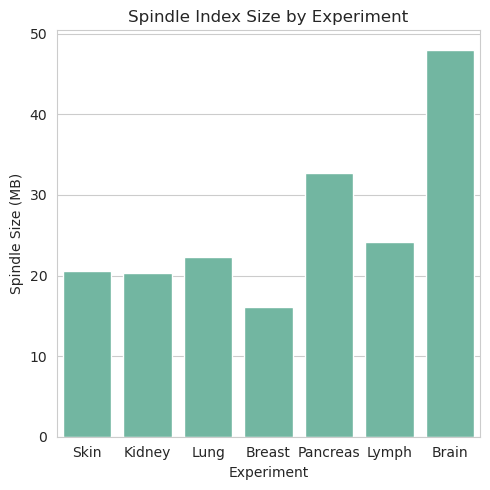

In [ ]:
# Create a barplot for spindle_size_MB, and index building time in two separate sub-plots

import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))
sns.barplot(x='experiment', y='spindle_size_MB', data=summary_df, ax=ax, order=summary_df.sort_values('num_cells')['experiment'])
plt.title('Spindle Index Size by Experiment')
plt.xlabel('Experiment')
plt.ylabel('Spindle Size (MB)')
plt.tight_layout()
plt.savefig('/data/sarkar_lab/Projects/spindle_dev/ISMB_notebook/figures/spindle_size_barplot.png', dpi=300)
plt.show()

In [74]:
# Create LaTeX table from summary_df
cols = ['experiment', 'num_cells', 'num_genes', 'index_time_raw', 'spindle_size_MB', 'h5ad_size_MB']
latex_table = summary_df[cols].sort_values('num_cells').to_latex(
    index=False,
    float_format=lambda x: f'{x:.2f}' if isinstance(x, float) else str(x),
    caption='Xenium Dataset Summary Statistics',
    label='tab:xenium_summary'
)
print(latex_table)

\begin{table}
\caption{Xenium Dataset Summary Statistics}
\label{tab:xenium_summary}
\begin{tabular}{lrrrrr}
\toprule
experiment & num_cells & num_genes & index_time_raw & spindle_size_MB & h5ad_size_MB \\
\midrule
Skin & 87499 & 382 & 33.47 & 20.61 & 51.64 \\
Kidney & 97560 & 377 & 28.63 & 20.34 & 33.94 \\
Lung & 162254 & 377 & 54.50 & 22.25 & 60.73 \\
Breast & 167780 & 313 & 50.21 & 16.14 & 103.27 \\
Pancreas & 190965 & 474 & 120.90 & 32.67 & 115.89 \\
Lymph & 377985 & 377 & 80.97 & 24.12 & 135.48 \\
Brain & 816769 & 480 & 675.91 & 48.03 & 525.59 \\
\bottomrule
\end{tabular}
\end{table}



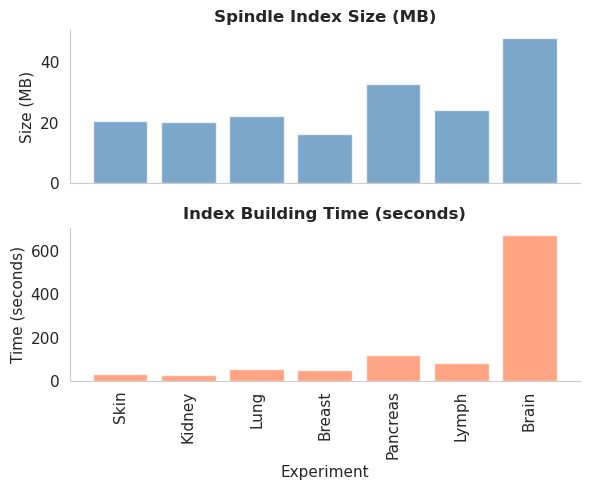

In [101]:
# Create barplots for spindle_size_MB and index_time_raw
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# Sort summary_df by num_cells for consistent ordering
summary_sorted = summary_df.sort_values('num_cells')

# Top subplot: spindle_size_MB
axes[0].bar(summary_sorted['experiment'], summary_sorted['spindle_size_MB'], color='steelblue', alpha=0.7)
axes[0].set_title('Spindle Index Size (MB)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Size (MB)', fontsize=11)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].grid(False)

# Bottom subplot: index_time_raw
axes[1].bar(summary_sorted['experiment'], summary_sorted['index_time_raw'], color='coral', alpha=0.7)
axes[1].set_title('Index Building Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Experiment', fontsize=11)
axes[1].set_ylabel('Time (seconds)', fontsize=11)
axes[1].tick_params(axis='x', rotation=90, labelsize=11)
axes[1].tick_params(axis='y', labelsize=11)
axes[1].grid(False)

sns.despine()
plt.tight_layout()
plt.savefig('/data/sarkar_lab/Projects/spindle_dev/ISMB_notebook/figures/index_stats_barplot_updown.pdf', dpi=500, bbox_inches='tight')
plt.show()